Lo primero que vamos a hacer es cargar el 5to año de datos cargando el dataset y volviendolo un dataframe de pandas

In [3]:
import pandas as pd
from scipy.io import arff

# 1.- Cargar el archivo ARFF
data, meta = arff.loadarff('datos/5year.arff')

# 2.- Convertir a DataFrame de pandas
df_corporativo = pd.DataFrame(data)

if 'class' in df_corporativo.columns:
    df_corporativo['class'] = df_corporativo['class'].astype(int)

# 3.- Exploracion inicial de las 64 variables
print(f"Total de filas y columnas: {df_corporativo.shape}")
display(df_corporativo.head())

Total de filas y columnas: (5910, 65)


,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class
0,0.088238,0.55472,0.01134,1.0205,-66.5200,0.342040,0.109490,0.57752,1.0881,0.32036,...,0.080955,0.275430,0.91905,0.002024,7.2711,4.7343,142.760,2.5568,3.2597,0
1,-0.006202,0.48465,0.23298,1.5998,6.1825,0.000000,-0.006202,1.06340,1.2757,0.51535,...,-0.028591,-0.012035,1.00470,0.152220,6.0911,3.2749,111.140,3.2841,3.3700,0
2,0.130240,0.22142,0.57751,3.6082,120.0400,0.187640,0.162120,3.05900,1.1415,0.67731,...,0.123960,0.192290,0.87604,0.000000,8.7934,2.9870,71.531,5.1027,5.6188,0
3,-0.089951,0.88700,0.26927,1.5222,-55.9920,-0.073957,-0.089951,0.12740,1.2754,0.11300,...,0.418840,-0.796020,0.59074,2.878700,7.6524,3.3302,147.560,2.4735,5.9299,0
4,0.048179,0.55041,0.10765,1.2437,-22.9590,0.000000,0.059280,0.81682,1.5150,0.44959,...,0.240400,0.107160,0.77048,0.139380,10.1180,4.0950,106.430,3.4294,3.3622,0


Checamos las descripciones de nuesto dataset para ver con que estamos trabajando

In [4]:
#Imprimir los nombres de los atributos y sus descripciones
print(" === Diccionario de varibales === ")

#Iteramos sobre los nombres de las varibales guardadas en la estructura meta
for attr_name in meta.names():
    print(f"{attr_name}: {meta[attr_name]}")

 === Diccionario de varibales === 
Attr1: ('numeric', None)
Attr2: ('numeric', None)
Attr3: ('numeric', None)
Attr4: ('numeric', None)
Attr5: ('numeric', None)
Attr6: ('numeric', None)
Attr7: ('numeric', None)
Attr8: ('numeric', None)
Attr9: ('numeric', None)
Attr10: ('numeric', None)
Attr11: ('numeric', None)
Attr12: ('numeric', None)
Attr13: ('numeric', None)
Attr14: ('numeric', None)
Attr15: ('numeric', None)
Attr16: ('numeric', None)
Attr17: ('numeric', None)
Attr18: ('numeric', None)
Attr19: ('numeric', None)
Attr20: ('numeric', None)
Attr21: ('numeric', None)
Attr22: ('numeric', None)
Attr23: ('numeric', None)
Attr24: ('numeric', None)
Attr25: ('numeric', None)
Attr26: ('numeric', None)
Attr27: ('numeric', None)
Attr28: ('numeric', None)
Attr29: ('numeric', None)
Attr30: ('numeric', None)
Attr31: ('numeric', None)
Attr32: ('numeric', None)
Attr33: ('numeric', None)
Attr34: ('numeric', None)
Attr35: ('numeric', None)
Attr36: ('numeric', None)
Attr37: ('numeric', None)
Attr38: ('nu

Ahora vamos al diagnostico de nulos

In [5]:
#1.- Contar cuantos nulos hay por cada columna
nulos_por_columna = df_corporativo.isnull().sum()

#2.- Filtrar para ver solo las columnas que realmente tienen nulos
columnas_con_nulos = nulos_por_columna[nulos_por_columna > 0]

#3.- Calcular que porcentaje de la base de datos representan esos nulos
porcentaje_nulos = (columnas_con_nulos / len(df_corporativo)) * 100

#4.- Crear una talbla resumen ordenada de mayor a menor
resumen_nulos = pd.DataFrame({
    'Total Nulos': columnas_con_nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values(by='Porcentaje (%)', ascending=False)

print(f"De las 64 variables, {len(columnas_con_nulos)} tienen datos faltantes. \n")
display(resumen_nulos.head(10))

De las 64 variables, 49 tienen datos faltantes. 



,Total Nulos,Porcentaje (%)
Attr37,2548,43.113367
Attr27,391,6.615905
Attr60,268,4.534687
Attr45,268,4.534687
Attr24,135,2.284264
Attr28,107,1.810491
Attr64,107,1.810491
Attr53,107,1.810491
Attr54,107,1.810491
Attr21,103,1.742809


En este caso, como metodo de aprendizaje usaremos 2 diferentes estrategias para la limpieza de datos

In [6]:
#Estrategia 1:
df_estrategia_1 = df_corporativo.copy()

#Calculamos la media de cada columna y rellenamos TODOS los nulos
#Excluimos la columna 'class' (el target) para no afectar la media
columnas_financieras = df_estrategia_1.columns.drop('class')
df_estrategia_1[columnas_financieras] = df_estrategia_1[columnas_financieras].fillna(df_estrategia_1[columnas_financieras].median())

#Estrategia 2:
df_estrategia_2 = df_corporativo.copy()

# Paso A: Eliminar columnas irrecuperables (más del 40% de nulos)
porcentaje_nulos = df_estrategia_2.isnull().sum() / len(df_estrategia_2)
columnas_basura = porcentaje_nulos[porcentaje_nulos > 0.40].index
df_estrategia_2 = df_estrategia_2.drop(columns=columnas_basura)

# Paso B: Imputar el resto con la mediana
columnas_restantes = df_estrategia_2.columns.drop('class')
df_estrategia_2[columnas_restantes] = df_estrategia_2[columnas_restantes].fillna(df_estrategia_2[columnas_restantes].median())

#Comparacion de resultador
print(f"Estrategia 1 (Básica) : {df_estrategia_1.shape[1]} columnas mantenidas. (Riesgo de sesgo alto por inventar el 43% de Attr37)")
print(f"Estrategia 2 (Híbrida): {df_estrategia_2.shape[1]} columnas mantenidas. (Eliminamos: {list(columnas_basura)})")

Estrategia 1 (Básica) : 65 columnas mantenidas. (Riesgo de sesgo alto por inventar el 43% de Attr37)
Estrategia 2 (Híbrida): 64 columnas mantenidas. (Eliminamos: ['Attr37'])


### Con los resultados de las dos estrategias podemos decir lo siguiente:

Estrategia 1 (65 columnas): Nos dice que conservaste absolutamente toda la tabla original. Para la variable Attr37 (la cual estaba vacía en un 43%), el código calculó la mediana de las empresas que sí tenían el dato y usó ese mismo número para rellenar los miles de huecos. El riesgo aquí es que le estamos "mintiendo" un poco al modelo matemático, dándole datos artificiales a casi la mitad de la muestra.

Estrategia 2 (64 columnas): Nos dice que el código analizó la calidad de la información, decidió que Attr37 estaba demasiado incompleta para ser salvada, y eliminó esa columna entera. Después, rellenó los huecos pequeños de las demás columnas. Perdiste una variable, pero la información que queda es mucho más real y confiable.


Ahora lo que vamos a hacer es comprobar si el remplazo funciono o no

In [7]:
print(f"Nulos en Estrategia 1: {df_estrategia_1.isnull().sum().sum()}")
print(f"Nulos en Estrategia 2: {df_estrategia_2.isnull().sum().sum()}")

Nulos en Estrategia 1: 0
Nulos en Estrategia 2: 0


Con esto podemos comprobar que en efecto el remplazo si funciono en las 2 estrategias

### ¿Cual estrategia es la mejor?

En este caso vamos a entrenar un modelo rapido (Random Forest) con la Estrategia 1, luego otro con la Estrategia 2, compararemos cual obtiene un mejor puntaje AUC-ROC (Lo cual es la metrica principal requerida por tu proyecto para la evaluacion).

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

def evaluar_estrategia(df, nombre_estrategia):
    #Separamos X(variables) y "y" (targer)
    X = df.drop('class', axis=1)
    y = df['class']

    #Dividimos los datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    #Entrenamos un modelo de Random Forest
    modelo = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
    modelo.fit(X_train, y_train)

    #Evaluamos el modelo
    predicciones = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, predicciones)

    print(f"AUC-ROC con {nombre_estrategia}: {auc:.4f}")

#Ponemos a competir abas bases de datos limpias
evaluar_estrategia(df_estrategia_1, "Estrategia 1 (Básica)")
evaluar_estrategia(df_estrategia_2, "Estrategia 2 (Híbrida)")


AUC-ROC con Estrategia 1 (Básica): 0.9271
AUC-ROC con Estrategia 2 (Híbrida): 0.9290


### Resultado de la Comparacion

Como podemos ver en el resultado, la "Estrategia 2" fue la ganadora con un AUC-ROC de 0.9290 sobre el de la "Estrategia 1" que fue de 0.9271.

Con esto podemos decir que el haber eliminado a la variable Attr37 no solo no afecto negativamente al modelo, si no que mejoro su capacidad predicitiva en comparacion con la estrategia que "inventaba" esos datos.

Ahora que tenemos nuestra base de datos ganadora entramos en el siguiente paso.

Como las 64 variables son demasiadas para la interpretacion en solitario vamos a reducir la dimensionalidad o seleccionar varibales priorizando su importancia. Para lograrlo usaremos el mismo poder el Random Forest. Lo que vamos a hacer es hacer uso de una propiedad del mismo, ya que mientras se contruyen cientos de arboles de decision, llevaremos un conteo exacto de que variables matematicas le fueron mas utiles para separar a las empresas en quiebra de las empresas sanas.

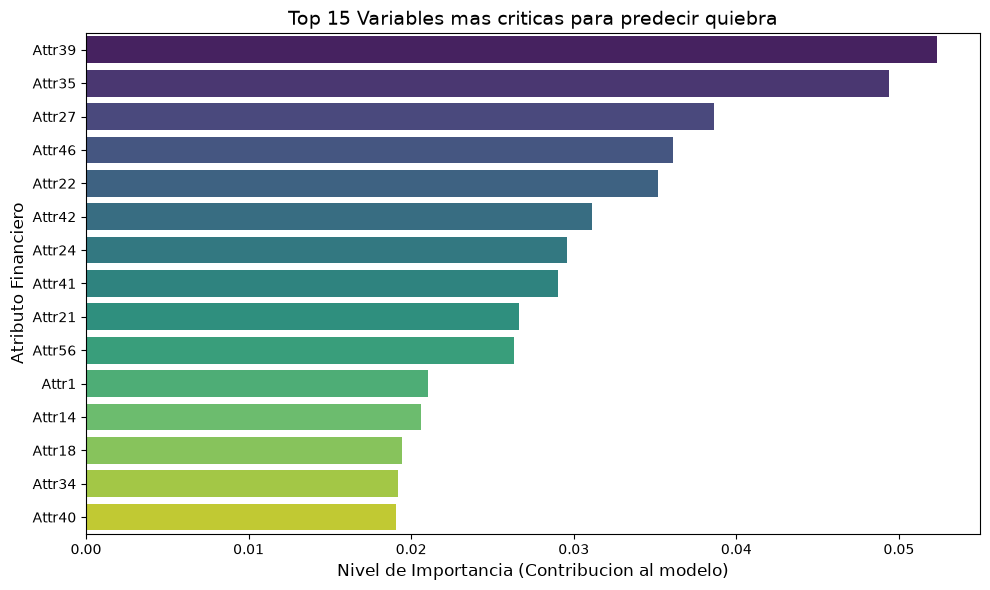

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

#1.- Usamos nuestra base de datos limpia de la Estrategia 2 (Híbrida)
X_final = df_estrategia_2.drop('class', axis=1)
y_final = df_estrategia_2['class']

#2.- Entrenamos el modelo para extraer la importancia de las variables
modelo_importancia = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
modelo_importancia.fit(X_final, y_final)

#3.- Extraemos y ordenamos la importancia de las variables
importancias = modelo_importancia.feature_importances_
df_importancia = pd.DataFrame({
    'Variable': X_final.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

#4.- Graficamos el Top 15
plt.figure(figsize=(10, 6))
#Usamos un mapa de colores
sns.barplot(data=df_importancia.head(15), x='Importancia', y='Variable', hue='Variable', palette='viridis', legend=False)
plt.title('Top 15 Variables mas criticas para predecir quiebra', fontsize=14)
plt.xlabel('Nivel de Importancia (Contribucion al modelo)', fontsize=12)
plt.ylabel('Atributo Financiero', fontsize=12)
plt.tight_layout()
plt.show()

### Resultados de la grafica

Con esto podemos notar que las tres variables que dominan totalmente el riesgo de quiebra son Attr39, Attr 35 y Attr27 las cuales son Margen de Beneficio sobre Ventas, Retorno sobre Activos (ROA) Operativo y Cobertura de Gastos Financieros.

Con esto podemos argumentar que el riesgo corporativo se reduce a tres preguntas clave:

1.- ¿El negocio principal es rentable?

2.- ¿Son eficientes con lo que tienen?

3.- ¿Pueden pagar los intereses de su deuda?

 === Resultados del Modelo === 
AUC-ROC Regresion Logistica: 0.8187
AUC-ROC Random Forest: 0.9143
----------------------------------------
Metricas de Negocio (Random Forest):
Coeficiente Gini: 0.8286
Estadistico KS: 0.7067


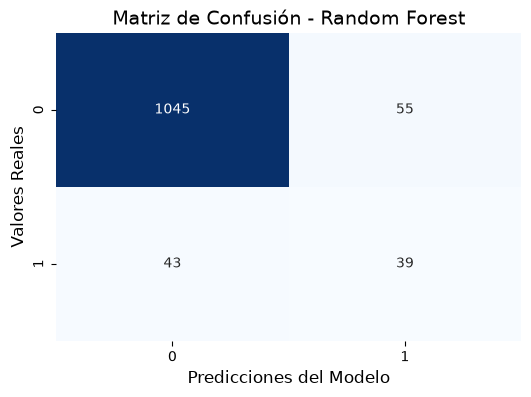

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#1.- Preparacion de datos usando las variables que pasaron el filtro de importancia
X = df_estrategia_2.drop('class', axis=1)
y = df_estrategia_2['class']

#Dividimos estratificando para mantener el 6.9% de quiebras en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Escalamiento indispensable para la Regresion Logistica
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#2.- Entrenamiento del Baseline (Regresion Logistica)
modelo_lr = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
modelo_lr.fit(X_train_scaled, y_train)
probs_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, probs_lr)

#3.- Entrenamiento del Ensamble (Random Forest)
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)
probs_rf = modelo_rf.predict_proba(X_test)[:, 1]
preds_rf = modelo_rf.predict(X_test)
auc_rf = roc_auc_score(y_test, probs_rf)

#4.- Calculo de Metricas Financieras (Gini y Ks) para el ganador
gini_rf = (2 * auc_rf) - 1

#Calculo de KS
def calcular_ks(y_true, y_prob):
    df = pd.DataFrame({'objetivo': y_true, 'probabilidad': y_prob}).sort_values('probabilidad', ascending=False)
    df['positivos_acumulados'] = df['objetivo'].cumsum() / df['objetivo'].sum()
    df['negativos_acumulados'] = (1 - df['objetivo']).cumsum() / (1 - df['objetivo']).sum()
    ks = np.max(np.abs(df['positivos_acumulados'] - df['negativos_acumulados']))
    return ks

ks_rf = calcular_ks(y_test, probs_rf)

#5.- Resultados finales

print(" === Resultados del Modelo === ")
print(f"AUC-ROC Regresion Logistica: {auc_lr:.4f}")
print(f"AUC-ROC Random Forest: {auc_rf:.4f}")
print("-" * 40)
print(f"Metricas de Negocio (Random Forest):")
print(f"Coeficiente Gini: {gini_rf:.4f}")
print(f"Estadistico KS: {ks_rf:.4f}")

#Matriz de Confusion
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, preds_rf), annot=True, fmt = 'd', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Random Forest', fontsize=14)
plt.xlabel('Predicciones del Modelo', fontsize=12)
plt.ylabel('Valores Reales', fontsize=12)
plt.show()

### Resultados del modelo Random Forest

Con los resultados y la grafica podemos dar por hecho varias cosas, primero que nada, este resultado demuestra que el algoritmo aprendio exitosamente las reglas subyacentes del riesgo financiero.

Podemos ver que el modelo leyo 1045 Verdaderos Negatvos, esto significa que el modelo aprobo el credito a 1045 empresas que efectivamente eran sanas.

Ademas de eso leyo 39 Verdaderos Positivos de empresas que iban a quebrar y les nego el credito lo cual es bueno.

Dio 55 Falsos Positivos siendo estas empresas que calisifco como riesgo de quiebra pero en realidad eran sanas.

Y por ultimo 43 Falsos Negativos, que son las emprezas que penso que eran seguras pero terminaron quebrando.

### Dashboard

Ahora lo que voy a hacer es tomar la base de datos limpia y le voy a intectar las predicciones para generar un semaforo de riesgo (Bajo, Medio, Alto) y empaquetar todo en un archivo .csv listo para crear un panel en Power BI

In [17]:
import pandas as pd

# 1. Hacemos una copia de nuestra base de datos limpia final
df_powerbi = df_estrategia_2.copy()

# 2. Inyectamos la inteligencia del modelo
# Pasamos todas las empresas (X) por el modelo para obtener su probabilidad de quiebra
df_powerbi['Probabilidad_Quiebra'] = modelo_rf.predict_proba(X)[:, 1]

# 3. Creamos el Semáforo de Riesgo (Feature Engineering para Negocios)
def categorizar_riesgo(probabilidad):
    if probabilidad < 0.20:
        return 'Bajo Riesgo (Seguro)'
    elif probabilidad < 0.50:
        return 'Riesgo Medio (Monitorear)'
    else:
        return 'Alto Riesgo (Alerta de Quiebra)'

df_powerbi['Categoria_Riesgo'] = df_powerbi['Probabilidad_Quiebra'].apply(categorizar_riesgo)

# 4. (Opcional pero recomendado) Renombrar el Top 3 de variables para que el Dashboard sea legible
df_powerbi = df_powerbi.rename(columns={
    'Attr39': 'Margen_Operativo',
    'Attr35': 'ROA_Operativo',
    'Attr27': 'Cobertura_Gastos_Financieros',
    'class': 'Quiebra_Historica'
})

# 5. Exportamos el archivo
nombre_archivo = 'datos/datos_riesgo_corporativo_bi.csv'
# Guardar el CSV indicando que use la coma como separador decimal
df_powerbi.to_csv(nombre_archivo, index=False, decimal=',')
print("Archivo actualizado con formato de decimales en español (coma).")

print(f"¡Exportación exitosa! Archivo generado: {nombre_archivo}")
print(f"Total de empresas exportadas: {len(df_powerbi)}")
print("\nDistribución de Riesgo Proyectada:")
print(df_powerbi['Categoria_Riesgo'].value_counts())

Archivo actualizado con formato de decimales en español (coma).
¡Exportación exitosa! Archivo generado: datos/datos_riesgo_corporativo_bi.csv
Total de empresas exportadas: 5910

Distribución de Riesgo Proyectada:
Categoria_Riesgo
Bajo Riesgo (Seguro)               4610
Riesgo Medio (Monitorear)           758
Alto Riesgo (Alerta de Quiebra)     542
Name: count, dtype: int64
